In [1]:
# Librerías
from pathlib import Path                   # Directorio de trabajo
import numpy as np                         # Cálculos numéricos
import pandas as pd                        # Manipulación de datos
import matplotlib.pyplot as plt            # Visualización de datos

In [2]:
# Raíz del proyecto
PROJECT_ROOT = Path().resolve().parents[1]
# Ruta a la carpeta de datos procesados
path = PROJECT_ROOT / "data" / "processed"

# Cargar los archivos de valores anuales
municipios = pd.read_csv(path / "municipios.csv")
produccion = pd.read_csv(path / "produccion_caldas_municipal_2007-2024.csv")
precipitacion = pd.read_csv(path / "precipitacion_caldas_anio_2005-2025.csv")
ndvi = pd.read_csv(path / "ndvi_caldas_anio_2005-2025.csv")
temperatura = pd.read_csv(path / "temperatura_caldas_anio_2005-2025.csv")
evapotranspiracion = pd.read_csv(path / "evapotranspiracion_caldas_anio_2005-2025.csv")

In [3]:
# Unificación de campo municipio
municipios = municipios.rename(columns={
    "MpNombre": "municipio",
})

produccion = produccion.rename(columns={
    "Municipio": "MP_NOMBRE",
    "MpNombre": "municipio",
    "Año": "anio",
    "Producción (t)": "produccion_t"
})

In [4]:
# Visualización de bases de datos
display(municipios.head())
display(produccion.head())
display(precipitacion.head())
display(ndvi.head())
display(temperatura.head())
display(evapotranspiracion.head())

,MpCodigo,municipio,MpAltitud,Depto,AREA_HA,DEPARTAMENTO,MUNICIPIO
0,17873,Villamaria,1944,Caldas,45487.084767,CALDAS,VILLAMARIA
1,17088,Belalcázar,1600,Caldas,11331.640905,CALDAS,BELALCAZAR
2,17174,Chinchiná,1378,Caldas,10932.067248,CALDAS,CHINCHINA
3,17665,San José,1750,Caldas,6096.031050,CALDAS,SAN JOSE
4,17877,Viterbo,1000,Caldas,11289.618868,CALDAS,VITERBO


,MP_NOMBRE,municipio,date,anio,Área sembrada (ha),Área cosechada (ha),Rendimiento (t/ha),produccion_t
0,AGUADAS,Aguadas,2007-12-31,2007,4626.0,4173.0,0.97,4063.0
1,ANSERMA,Anserma,2007-12-31,2007,7125.0,5485.0,1.30,7131.0
2,ARANZAZU,Aranzazu,2007-12-31,2007,2597.0,2222.0,1.01,2254.0
3,BELALCAZAR,Belalcázar,2007-12-31,2007,3734.0,3196.0,1.20,3835.0
4,CHINCHINA,Chinchiná,2007-12-31,2007,5632.0,5631.0,1.63,9203.0


,municipio,date,anio,precip_mm,precip_mean_mm,precip_max_mm,n_pixeles
0,Aguadas,2005-12-31,2005,2381.398658,6.503702,46.495879,27.0
1,Aguadas,2006-12-31,2006,2531.594393,6.926494,38.747605,27.0
2,Aguadas,2007-12-31,2007,2660.352575,7.242478,70.681276,27.0
3,Aguadas,2008-12-31,2008,3191.778940,8.714073,53.196217,27.0
4,Aguadas,2009-12-31,2009,2173.098247,5.956387,68.452368,27.0


,municipio,date,anio,ndvi_mean,ndvi_median,ndvi_min,ndvi_max,ndvi_stdDev,n_pixeles
0,Aguadas,2005-12-31,2005,0.703595,0.738350,0.0050,0.9994,0.141924,7979.958333
1,Aguadas,2006-12-31,2006,0.691045,0.731616,0.0121,0.9987,0.150294,7979.500000
2,Aguadas,2007-12-31,2007,0.687805,0.731916,0.0089,0.9991,0.158511,7980.083333
3,Aguadas,2008-12-31,2008,0.678829,0.729487,0.0087,0.9992,0.165530,7979.791667
4,Aguadas,2009-12-31,2009,0.705580,0.748844,0.0000,0.9992,0.147902,7979.750000


,municipio,date,anio,temp_mean,temp_min,temp_max,n_pixeles
0,Aguadas,2005-12-31,2005,17.463806,10.194100,26.278290,11.0
1,Aguadas,2006-12-31,2006,17.305318,10.457883,27.345317,11.0
2,Aguadas,2007-12-31,2007,17.091233,10.312653,27.030563,11.0
3,Aguadas,2008-12-31,2008,16.696953,10.095356,25.342598,11.0
4,Aguadas,2009-12-31,2009,17.257226,10.502291,27.553357,11.0


,municipio,date,anio,et_real_mm,et_potencial_mm,n_pixeles
0,Aguadas,2005-12-31,2005,1107.821281,1113.321386,38.0
1,Aguadas,2006-12-31,2006,1100.508614,1113.070667,38.0
2,Aguadas,2007-12-31,2007,1037.679544,1100.944579,38.0
3,Aguadas,2008-12-31,2008,1080.767000,1084.587614,38.0
4,Aguadas,2009-12-31,2009,1125.788456,1129.578351,38.0


In [5]:
produccion.columns

Index(['MP_NOMBRE', 'municipio', 'date', 'anio', 'Área sembrada (ha)',
       'Área cosechada (ha)', 'Rendimiento (t/ha)', 'produccion_t'],
      dtype='object')

In [6]:
# Selección de variables relevantes
mun = municipios[["municipio", "MpAltitud"]].copy()
prod = produccion[["municipio", "date", "anio", "Área sembrada (ha)", "Rendimiento (t/ha)", "produccion_t"]].copy()
prec = precipitacion[["municipio", "anio", "precip_mm", "precip_mean_mm", "precip_max_mm"]].copy()
ndvi_s = ndvi[["municipio", "anio", "ndvi_mean", "ndvi_min", "ndvi_max"]].copy()
temp = temperatura[["municipio", "anio","temp_mean", "temp_min", "temp_max"]].copy()
evapo = evapotranspiracion[["municipio", "anio", "et_real_mm", "et_potencial_mm"]].copy()

In [7]:
# Consolidación de base de datos anuales
df = prod.copy()                                                       # Base principal
df = df.merge(prec, on=["municipio", "anio"], how="left")              # Agregar Precipitación
df = df.merge(ndvi_s, on=["municipio", "anio"], how="left")            # Agregar NDVI
df = df.merge(temp, on=["municipio", "anio"], how="left")              # Agregar Temperatura
df = df.merge(evapo, on=["municipio", "anio"], how="left")             # Agregar Evapotranspiración
df = df.merge(mun, on="municipio", how="left")                         # Agregar Altitud

In [9]:
df

,municipio,date,anio,Área sembrada (ha),Rendimiento (t/ha),produccion_t,precip_mm,precip_mean_mm,precip_max_mm,ndvi_mean,ndvi_min,ndvi_max,temp_mean,temp_min,temp_max,et_real_mm,et_potencial_mm,MpAltitud
0,Aguadas,2007-12-31,2007,4626.00,0.97,4063.00,2660.352575,7.242478,70.681276,0.687805,0.0089,0.9991,17.091233,10.312653,27.030563,1037.679544,1100.944579,2181
1,Anserma,2007-12-31,2007,7125.00,1.30,7131.00,2168.859973,5.904019,37.790492,0.701928,0.0156,0.9992,17.881403,11.112138,26.024901,1097.347859,1155.260144,1765
2,Aranzazu,2007-12-31,2007,2597.00,1.01,2254.00,2106.546668,5.732379,72.617682,0.604989,0.0090,0.9987,14.965246,7.455178,24.199591,983.716034,1007.600223,1908
3,Belalcázar,2007-12-31,2007,3734.00,1.20,3835.00,2429.582959,6.615046,61.028071,0.729644,0.0636,0.9993,17.887070,11.306247,28.488250,1095.931637,1161.129720,1600
4,Chinchiná,2007-12-31,2007,5632.00,1.63,9203.00,2530.997565,6.891550,51.884429,0.735379,-0.1790,0.9990,17.040641,10.057549,27.141381,1095.694041,1152.459587,1378
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,San José,2024-12-31,2024,1584.60,0.54,615.51,2173.660110,5.939656,63.528192,0.730889,0.0242,0.9977,18.667392,12.796018,29.871429,1248.156293,1282.179530,1750
446,Supia,2024-12-31,2024,1351.45,1.11,1168.41,2250.343809,6.148640,52.645529,0.702751,0.0317,0.9995,19.076268,11.545944,27.906270,1109.156731,1290.798420,1184
447,Victoria,2024-12-31,2024,103.57,1.49,118.38,3363.916087,9.193623,66.538346,0.768125,-0.0053,0.9996,26.444069,18.058960,37.466493,1200.187197,1495.616034,675
448,Villamaria,2024-12-31,2024,1470.50,0.98,1102.42,2088.704416,5.716982,52.718158,0.576598,-0.1045,0.9995,11.779751,5.635381,20.617843,970.047567,1001.842739,1944


In [ ]:
# Seleccción de variables climáticas
vars_climaticas = [
    "precip_mm",
    "precip_mean_mm",
    "precip_max_mm",
    "temp_mean",
    "temp_min",
    "temp_max",
    "et_real_mm",
    "et_potencial_mm",
    "ndvi_mean"
]

In [14]:
# Correlación entre altitud y variables climáticas
corr_altitud = df[["MpAltitud"] + vars_climaticas].corr()
corr_altitud["MpAltitud"].sort_values(ascending=False)

MpAltitud          1.000000
precip_max_mm     -0.253415
precip_mean_mm    -0.353346
precip_mm         -0.353755
ndvi_mean         -0.528312
et_real_mm        -0.647631
et_potencial_mm   -0.669458
temp_max          -0.680860
temp_mean         -0.733736
temp_min          -0.733761
Name: MpAltitud, dtype: float64

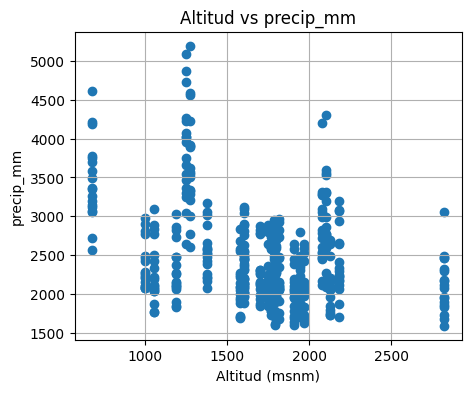

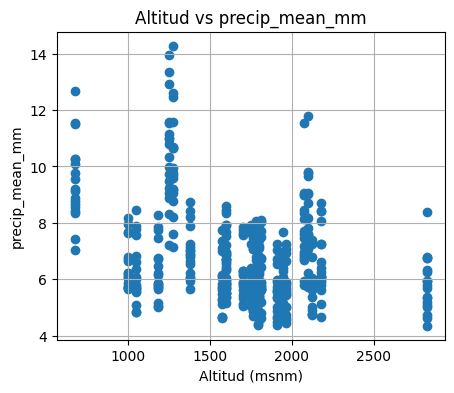

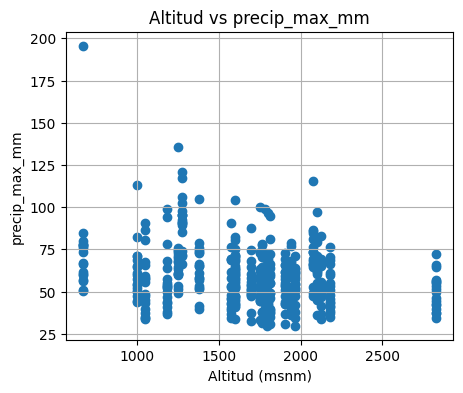

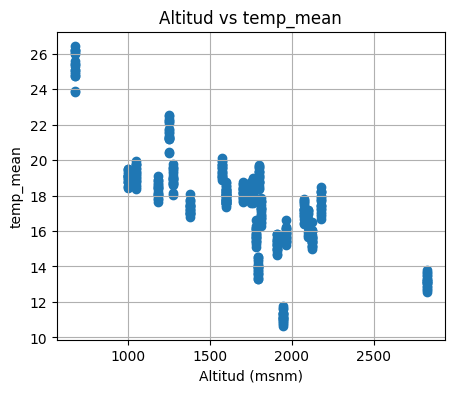

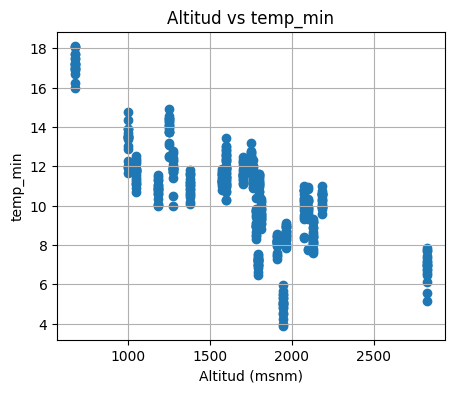

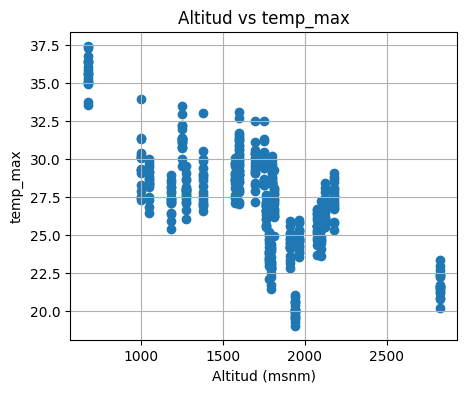

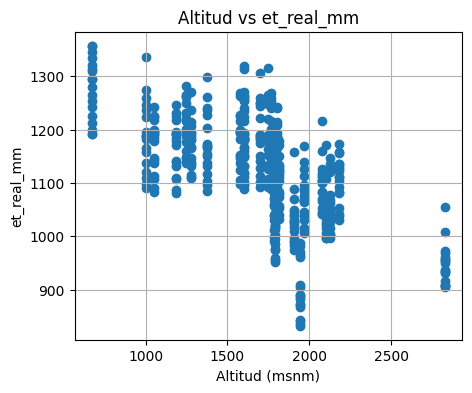

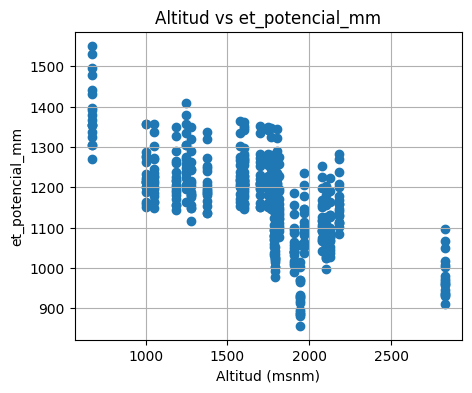

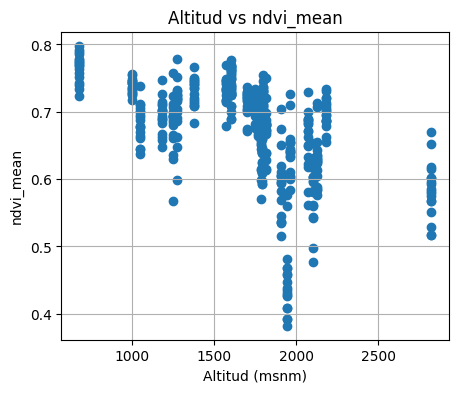

In [15]:
# Visualización de relación entre altitud y variables climáticas
for var in vars_climaticas:
    plt.figure(figsize=(5, 4))
    plt.scatter(df["MpAltitud"], df[var])
    
    plt.xlabel("Altitud (msnm)")
    plt.ylabel(var)
    plt.title(f"Altitud vs {var}")
    
    plt.grid(True)
    plt.show()

In [17]:
# Agregado municipal (quita ruido temporal)
df_mun = df.groupby("municipio").mean(numeric_only=True).reset_index()

corr_altitud_mun = df_mun[["MpAltitud"] + vars_climaticas].corr()
corr_altitud_mun["MpAltitud"].sort_values(ascending=False)

MpAltitud          1.000000
precip_mean_mm    -0.447707
precip_mm         -0.448329
precip_max_mm     -0.481547
ndvi_mean         -0.579846
temp_max          -0.714388
temp_mean         -0.742470
et_real_mm        -0.746752
temp_min          -0.750894
et_potencial_mm   -0.774239
Name: MpAltitud, dtype: float64

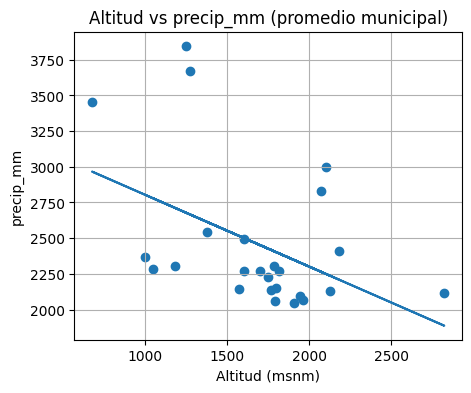

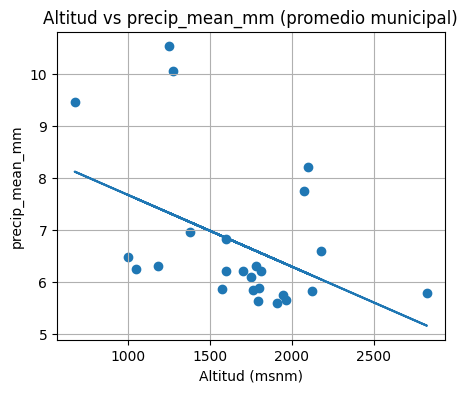

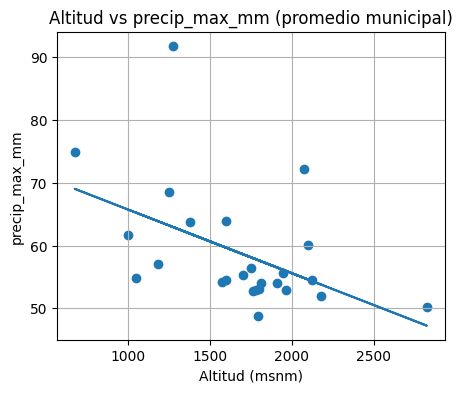

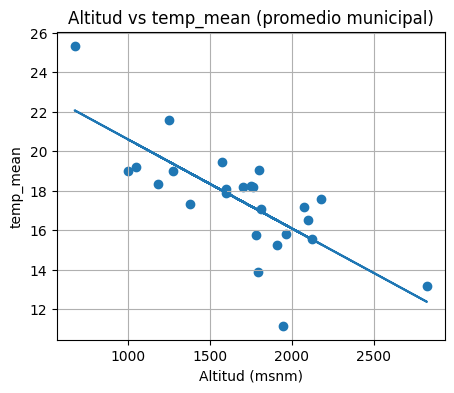

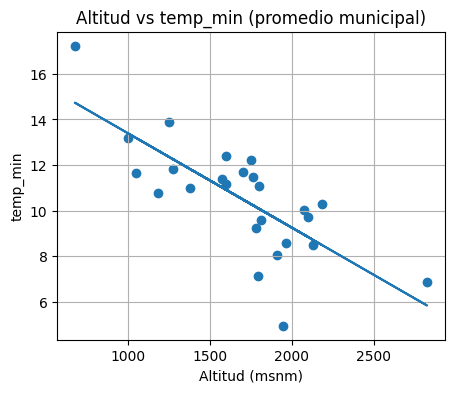

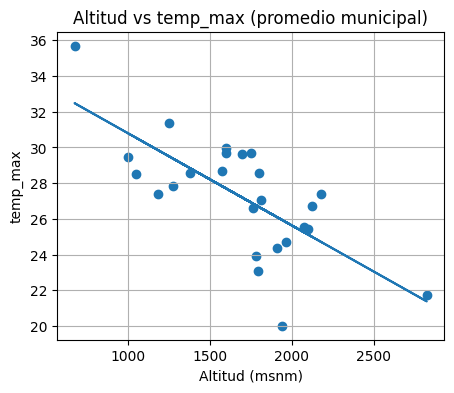

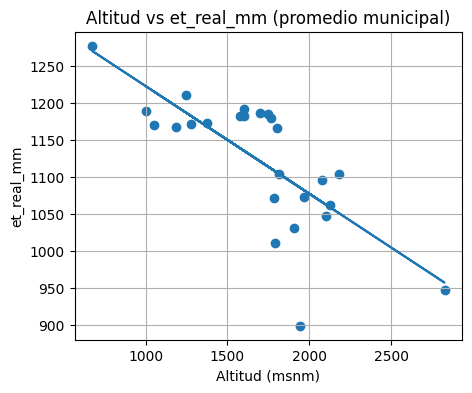

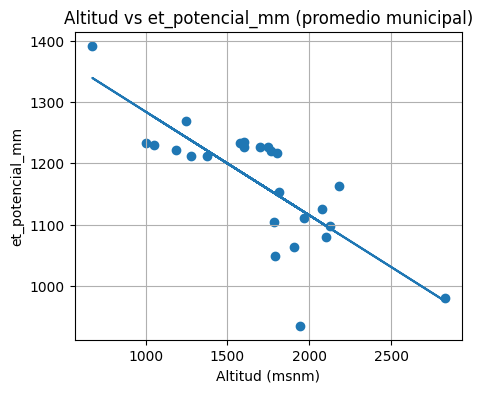

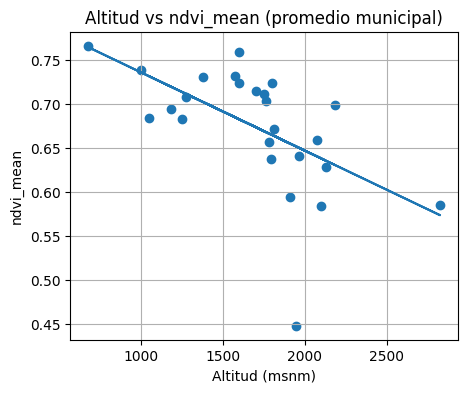

In [18]:
for var in vars_climaticas:
    plt.figure(figsize=(5, 4))
    plt.scatter(df_mun["MpAltitud"], df_mun[var])
    
    # línea de tendencia
    z = np.polyfit(df_mun["MpAltitud"], df_mun[var], 1)
    p = np.poly1d(z)
    plt.plot(df_mun["MpAltitud"], p(df_mun["MpAltitud"]))
    
    plt.xlabel("Altitud (msnm)")
    plt.ylabel(var)
    plt.title(f"Altitud vs {var} (promedio municipal)")
    
    plt.grid(True)
    plt.show()

In [ ]:
# Validación de relación entre altitud y variables climáticas
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = df_mun[[
    "precip_mm",
    "temp_mean",
    "et_real_mm",
    "ndvi_mean"
]]

y = df_mun["MpAltitud"]

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

r2_altitud = r2_score(y, y_pred)
print("R2 (Altitud ~ Clima):", r2_altitud)

R2 (Altitud ~ Clima): 0.6347618794315821


##### El valor obtenido debe interpretarse: 
* Sí R2 > 0.80 --> El clima está capturando la Altitud (Alta redundancia)
* Sí 0.5 > R2 > 0.80 --> El clima está capturando parcialmente la Altitud (Redundancia moderada)
* Sí 0.5 > R2 --> El clima está independiente a la Altitud (Aporta información)   

A coninuación se prueban 2 modelos (con y sin altitud) para validar sí efectivamente esta variable aporta al modelo de producción

In [24]:
# Modelo sin altitud
X1 = df_mun[[
    "precip_mm",
    "temp_mean",
    "et_real_mm",
    "ndvi_mean"
]]

y = df_mun["produccion_t"]

model1 = LinearRegression()
model1.fit(X1, y)

r2_sin_alt = model1.score(X1, y)
print("R2 sin altitud:", r2_sin_alt)

R2 sin altitud: 0.19700055574834296


In [23]:
# Modelo con altitud
X2 = df_mun[[
    "precip_mm",
    "temp_mean",
    "et_real_mm",
    "ndvi_mean",
    "MpAltitud"
]]

model2 = LinearRegression()
model2.fit(X2, y)

r2_con_alt = model2.score(X2, y)
print("R2 con altitud:", r2_con_alt)

R2 con altitud: 0.36552375054886044


In [22]:
# Comparación de modelos
print("Mejora por altitud:", r2_con_alt - r2_sin_alt)

Mejora por altitud: 0.16852319480051747


##### El valor obtenido debe interpretarse: 
* Sí mejora = 0 (0%)--> Altitud no aporta (Redundante)
* Sí 0.01 > mejora > 0.03 (1 - 3%) --> Altitud aporta marginalmente (Medianamente redundante)
* Sí mejora > 0.05 (> 5%) --> Altitud aporta información relevante

In [27]:
import statsmodels.api as sm

# Residualizar producción respecto al clima
X_clima = df_mun[[
    "precip_mm",
    "temp_mean",
    "et_real_mm",
    "ndvi_mean"
]]
X_clima = sm.add_constant(X_clima)

model_prod = sm.OLS(df_mun["produccion_t"], X_clima).fit()
resid_prod = model_prod.resid

# Correlación con altitud
corr_parcial = np.corrcoef(resid_prod, df_mun["MpAltitud"])[0,1]

print("Correlación parcial (altitud vs producción):", corr_parcial)

Correlación parcial (altitud vs producción): 0.27686003481774923


#### Se agrega la variable Altitud al modelo de análisis ya que su independencia lineal puede mejorar la detección de micro-climas
* No está totalmente capturando o describiendo el clima
* Se muestra parcialmente correlacionada con el clima
* Aporta al modelo (inclusive de manera lineal)